[bağlantı metni](https://)

## **Importing Libraries**

In [ ]:
!pip install pydub

In [ ]:
!apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [ ]:
import os
import librosa
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import shutil
import soundfile as sf
import pandas as pd
from pydub import AudioSegment
from tqdm import tqdm
from tensorflow.image import resize
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
classes = ['rock', 'reggae', 'pop', 'metal', 'jazz', 'hiphop', 'disco', 'country', 'classical', 'blues']

## **Visualizing Single Audio**

In [ ]:
dataSetPath = '/content/drive/MyDrive/Music Genre Classification/Data'
audioName = dataSetPath + '/blues.00000.wav'

print(os.listdir(dataSetPath))

['features_30_sec.csv', 'features_3_sec.csv', 'images_original', 'genres_original', 'blues.00000.wav', 'Test Data', 'Test Data 2']


In [ ]:
y,sr = librosa.load(audioName, sr = 44100)
plt.figure(figsize = (14,5))
librosa.display.waveshow(y, sr = sr)

## **Playing Audio**

In [ ]:
from IPython.display import Audio
Audio(data = y, rate = sr)

### **Visualization on Chunks of Audio**

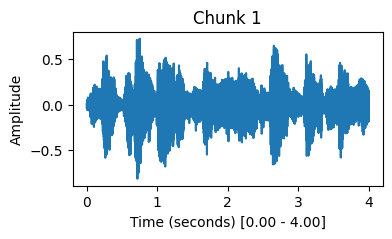

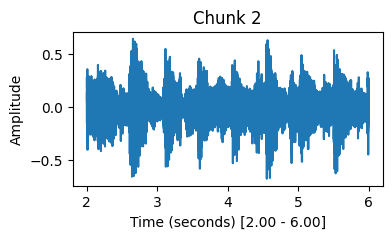

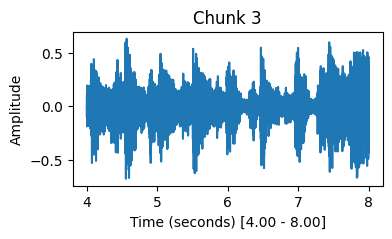

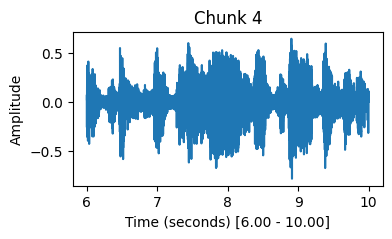

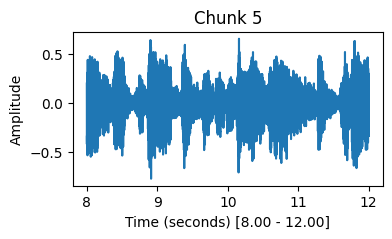

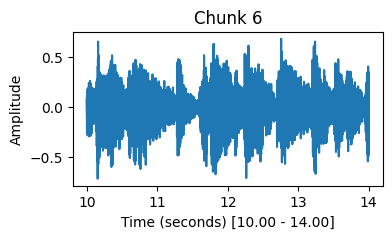

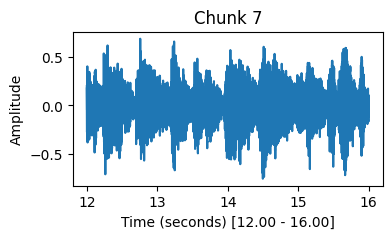

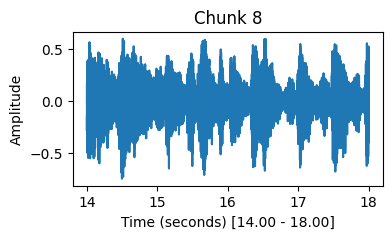

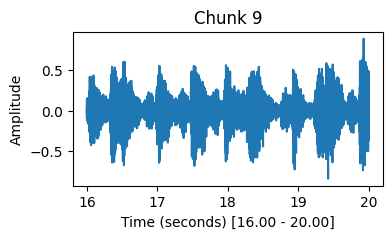

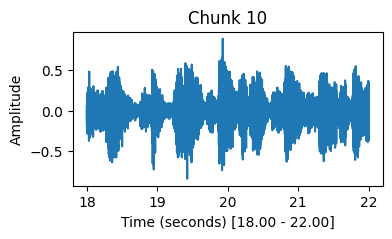

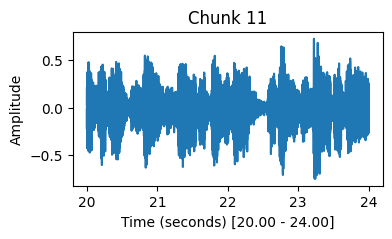

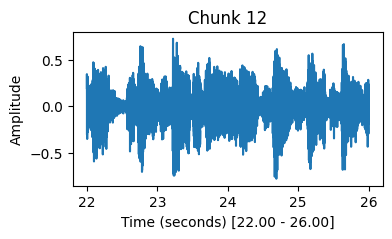

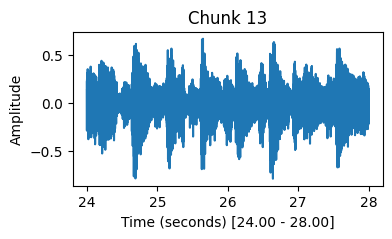

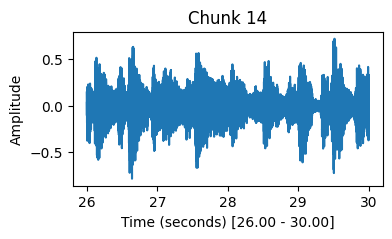

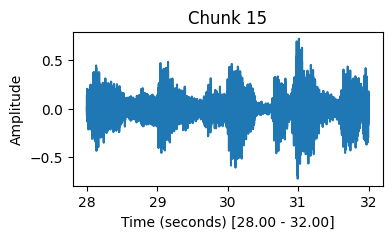

In [ ]:
dataSetPath = '/content/drive/MyDrive/Music Genre Classification/Data'
audioName = dataSetPath + '/blues.00000.wav'
y,sr = librosa.load(audioName, sr = None) # sr = None deme sebebimiz, orjinal 'sample rate' değerini korumak istememiz.

chunkDuration = 4
overlapDuration = 2

# Convert duration to sample
chunkSamples = chunkDuration * sr
overlapSamples = overlapDuration * sr

# Chunk number calculation
numChunks = int(np.ceil((len(y) - chunkSamples) / (chunkSamples - overlapSamples))) + 1

# Iterate over each chunks
for i in range(numChunks):
    start = i * (chunkSamples - overlapSamples)
    end = start + chunkSamples
    chunk = y[start:end]

    start_time_sec = start / sr
    end_time_sec = end / sr

    time_axis = np.linspace(start_time_sec, end_time_sec, len(chunk))

    plt.figure(figsize=(4, 2))
    plt.plot(time_axis, chunk)
    plt.xlabel(f'Time (seconds) [{start_time_sec:.2f} - {end_time_sec:.2f}]')
    plt.ylabel('Amplitude')
    plt.title(f'Chunk {i+1}')
    plt.show()

## **Single Audio Melspectrogram Visualization**

In [ ]:
def plotMelspectrogram(y, sr):
  spectogram = librosa.feature.melspectrogram(y = y, sr = sr)
  spectogramDb = librosa.power_to_db(spectogram, ref = np.max)
  plt.figure(figsize = (10, 4))
  librosa.display.specshow(spectogramDb, sr = sr, x_axis = 'time', y_axis = 'mel')
  plt.colorbar(format = '%2.0f dB')
  plt.title("Spectogram")
  plt.tight_layout()
  plt.show()

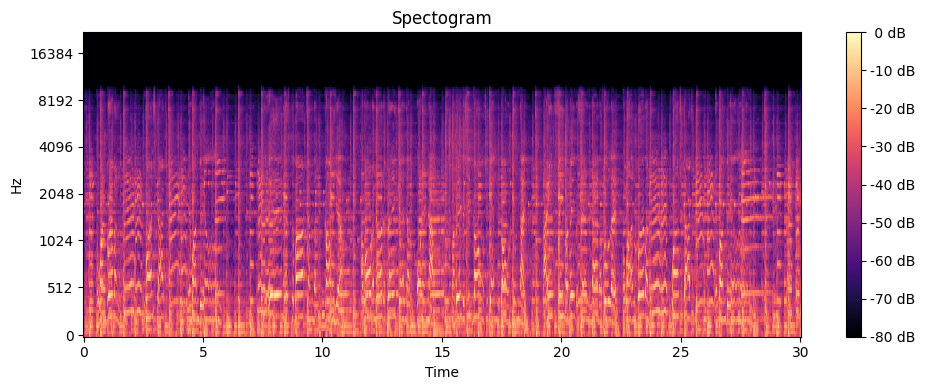

In [ ]:
dataSetPath = '/content/drive/MyDrive/Music Genre Classification/Data'
audioName = dataSetPath + '/blues.00000.wav'
y,sr = librosa.load(audioName, sr = 44100)
plotMelspectrogram(y, sr)

## **Chunk's Melspectrogram Visualization**

In [ ]:
def plotMelspectrogramChunks(y, sr):
    chunkDuration = 4
    overlapDuration = 2

    chunkSamples = chunkDuration * sr
    overlapSamples = overlapDuration * sr

    numChunks = int(np.ceil((len(y) - chunkSamples) / (chunkSamples - overlapSamples))) + 1

    for i in range(numChunks):
        start = i * (chunkSamples - overlapSamples)
        end = start + chunkSamples
        chunk = y[start:end]

        start_time_sec = start / sr
        end_time_sec = end / sr

        spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sr)
        spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(spectrogram_db, sr=sr, x_axis=None, y_axis='mel')
        plt.colorbar(format='%2.0f dB')
        plt.title(f'Chunk {i+1} Mel Spectrogram ({start_time_sec:.2f} - {end_time_sec:.2f} seconds)')

        num_ticks = 5
        time_ticks = np.linspace(0, spectrogram_db.shape[1], num_ticks)
        time_labels = np.linspace(start_time_sec, end_time_sec, num_ticks)
        plt.xticks(time_ticks, [f'{t:.2f}' for t in time_labels])

        plt.xlabel('Time (seconds)')
        plt.tight_layout()
        plt.show()


In [ ]:
dataSetPath = '/content/drive/MyDrive/GTZAN/Data'
audioName = dataSetPath + '/blues.00000.wav'
y,sr = librosa.load(audioName, sr = 44100)
plotMelspectrogramChunks(y = y, sr = sr)

Output hidden; open in https://colab.research.google.com to view.

## **All Data Set Melspectrogram**

In [ ]:
dataSetPath = '/content/drive/MyDrive/GTZAN/Data/genres_original'
classes = ['rock', 'reggae', 'pop', 'metal', 'jazz', 'hiphop', 'disco', 'country', 'classical', 'blues']

In [ ]:
def MelspectrogramChunks(y, sr, targetShape, data, labels, iClass):
    chunkDuration = 4
    overlapDuration = 2

    chunkSamples = chunkDuration * sr
    overlapSamples = overlapDuration * sr

    numChunks = int(np.ceil((len(y) - chunkSamples) / (chunkSamples - overlapSamples))) + 1

    for i in range(numChunks):
        start = i * (chunkSamples - overlapSamples)
        end = start + chunkSamples
        chunk = y[start:end]

        start_time_sec = start / sr
        end_time_sec = end / sr

        spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sr)

        resizedSpectrogram = resize(np.expand_dims(spectrogram, axis = -1), targetShape)

        data.append(resizedSpectrogram)
        labels.append(iClass)

In [ ]:
def loadAndPreprocessData(dataDir, classes, targetShape = (150, 150)):
  data = []
  labels = []

  for iClass, className in enumerate(classes):
    classDir = os.path.join(dataDir, className)
    print("Processing: ", className)
    for fileName in os.listdir(classDir):
      if fileName.endswith('.wav'):
        filePath = os.path.join(classDir, fileName)
        try:
          audioData, sampleRate = librosa.load(filePath, sr=None)
          MelspectrogramChunks(audioData, sampleRate, targetShape, data, labels, iClass)
        except Exception as e:
          print(f"Hata oluştu: {filePath} dosyası atlandı. Hata: {e}")
  return np.array(data), np.array(labels)

In [ ]:
data, labels = loadAndPreprocessData(dataSetPath, classes)

In [ ]:
labels = to_categorical(labels, num_classes = len(classes))

In [ ]:
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/data.npy', data)
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/labels.npy', labels)

## **Splitting Dataset into Training and Test Set**

In [ ]:
from sklearn.model_selection import train_test_split

XTrain, XTest, YTrain, YTest = train_test_split(data, labels, test_size = 0.2, random_state = 42)

In [ ]:
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/XTrain.npy', XTrain)
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/YTrain.npy', YTrain)
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/XTest.npy', XTest)
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/YTest.npy', YTest)

In [ ]:
XTrain[0].shape

(150, 150, 1)

In [ ]:
XTrain = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/XTrain.npy')
YTrain = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/YTrain.npy')
XTest = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/XTest.npy')
YTest = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/YTest.npy')

In [ ]:
data = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/data.npy')
labels = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/labels.npy')

## **Building Model**

In [ ]:
model = tf.keras.models.Sequential()

Sequential Model: Katmanların sırayla birbirine eklendiği basit bir yapıdır. Görüntü işleme için yaygın olarak kullanılır.

In [ ]:
model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu', input_shape = (128, 128, 1)))
model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Conv2D(16, kernel_size=(3, 3), padding='same', activation='relu'):

  * 32 Filtre: Görüntüdeki temel özellikleri (kenar, köşe) yakalar.

  * Kernel Size (3x3): 3x3 boyutlu filtreler kullanılır.

  * Padding='same': Çıktı boyutu, giriş boyutuyla aynı tutulur.

  * Activation='relu': Negatif değerleri sıfırlayarak doğrusal olmayan özellik
  çıkarımı sağlar.

  * input_shape=(210,210,1): Giriş görüntüsünün boyutu (210x210 piksel, 1 kanal gri tonlamalı).

MaxPooling2D(pool_size=(2, 2), strides=2):

  * Havuzlama (Pooling): Boyutları yarıya indirir, hesaplama yükünü azaltır.

In [ ]:
model.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 64, kernel_size = 3, activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [ ]:
model.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 128, kernel_size = 3, activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [ ]:
model.add(Dropout(0.3))

* **Dropout**, bir düzenleme (regularization) tekniğidir ve özellikle aşırı öğrenmeyi (overfitting) önlemek için kullanılır. Modelin eğitim sırasında bazı nöronları rastgele devre dışı bırakmasını sağlar. Bu, modelin veri üzerindeki genelleme yeteneğini artırır ve yalnızca eğitim verisine aşırı bağımlı hale gelmesini engeller.

* **0.3**:
Bu, %30 oranında nöronun her eğitim adımında rastgele devre dışı bırakılacağını (yani kullanılmayacağını) belirtir. Geriye kalan %70 nöron ile öğrenme gerçekleşir.

In [ ]:
model.add(Conv2D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 256, kernel_size = 3, activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [ ]:
model.add(Conv2D(filters = 512, kernel_size = 3, padding = 'same', activation = 'relu'))
model.add(Conv2D(filters = 512, kernel_size = 3, activation = 'relu'))
model.add(MaxPool2D(pool_size = 2, strides = 2))

In [ ]:
model.add(Dropout(0.3))

In [ ]:
model.add(Flatten())

* Flatten: Konvolüsyon katmanlarından çıkan çok boyutlu veriyi tek boyutlu hale getirir. Bu adım, veriyi tam bağlantılı (Dense) katmanlara hazırlamak içindir.


In [ ]:
model.add(Dense(units = 1200, activation = 'relu'))

* **Dense (Tam Bağlantılı Katman)**, yapay sinir ağlarında en yaygın kullanılan katman türlerinden biridir. Bu katman, tüm giriş nöronlarını çıkış nöronlarına bağlar ve her bir nöronun diğer tüm nöronlarla etkileşime girmesini sağlar.

* **units=1200**:
Bu katmanda 1200 adet nöron bulunur. Her bir nöron, bir ağırlık (w) ve bias (b) değeriyle çalışır.
Giriş verisinin her bir özelliği bu 1200 nöron ile bağlantılıdır.
Bu nöronlar, bir sonraki katmana özellik çıkarımı sağlar.


In [ ]:
model.add(Dropout(0.45))

In [ ]:
model.add(Dense(units = len(classes), activation = 'softmax'))

* Dense(10, activation='softmax'): Çıkış katmanı. 10 sınıf için olasılık tahmini yapar. Softmax, toplamı 1 olan olasılıklar döndürür ve en yüksek olasılıkta olan sınıfı seçer.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 31, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │     2,458,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,182,458 (27.40 MB)

 Trainable params: 7,182,458 (27.40 MB)

 Non-trainable params: 0 (0.00 B)

### **Compile the Model**

In [ ]:
model.compile(optimizer = Adam(learning_rate = 0.0001), loss = 'categorical_crossentropy', metrics = ['accuracy'])

### **Training the Model**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

train_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(XTrain, YTrain, batch_size=32)
test_generator = test_datagen.flow(XTest, YTest, batch_size=32)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_path = '/content/drive/MyDrive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/best_model.keras'

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1990 - loss: 2.1508
Epoch 1: val_loss improved from inf to 1.60229, saving model to /content/drive/MyDrive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.1993 - loss: 2.1499 - val_accuracy: 0.4357 - val_loss: 1.6023 - learning_rate: 1.0000e-04
Epoch 2/50
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4681 - loss: 1.5141
Epoch 2: val_loss improved from 1.60229 to 1.46564, saving model to /content/drive/MyDrive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4686 - loss: 1.5128 - val_accuracy: 0.5082 - val_loss: 1.4656 - learning_rate: 1.0000e-04
Epoch 3/50
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5783 - loss: 1.2037
Epoch 3: val_loss improved from 1.46564 to 1.01088, saving model to /content/drive/MyDrive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━

In [ ]:
import json
with open('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/trainingHistory.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
from tensorflow.keras.models import load_model
loadedModel = load_model('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/best_model.keras')

In [ ]:
import json

with open('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/trainingHistory.json', 'r') as f:
    trainingHistoryData = json.load(f)

In [ ]:
trainingHistoryData.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

## **Model Evaluation**

In [ ]:
trainLoss, trainAccuracy = loadedModel.evaluate(XTrain, YTrain)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9932 - loss: 0.0278


In [ ]:
vallLoss, vallAccuracy = loadedModel.evaluate(XTest, YTest)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9088 - loss: 0.3306


### **Accuracy & Loss Visualization**

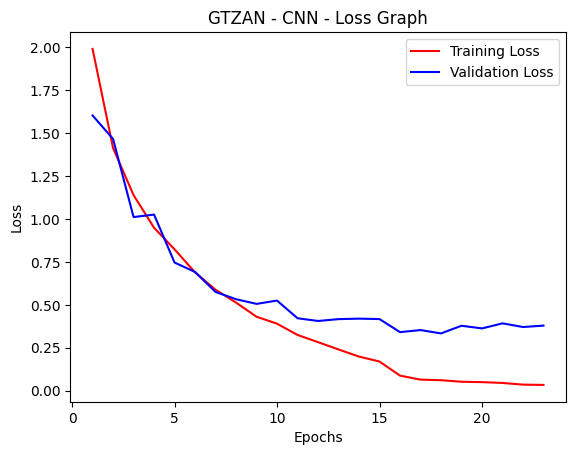

In [ ]:
epochs = range(1, len(trainingHistoryData['loss']) + 1)

plt.plot(epochs, trainingHistoryData['loss'], label="Training Loss", color='red')
plt.plot(epochs, trainingHistoryData['val_loss'], label="Validation Loss", color='blue')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("GTZAN - CNN - Loss Graph")
plt.legend()
plt.show()


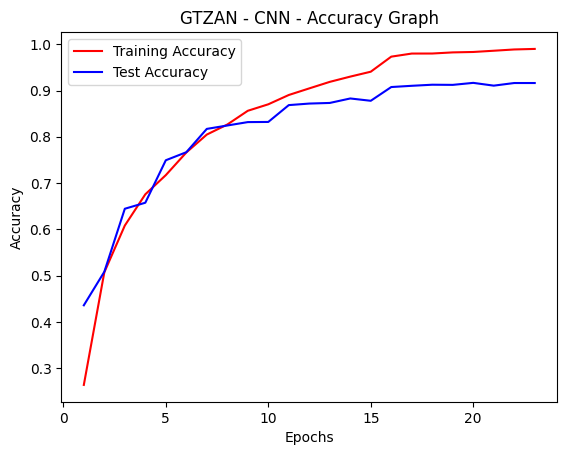

In [ ]:
epochs = range(1, len(trainingHistoryData['loss']) + 1)

plt.plot(epochs, trainingHistoryData['accuracy'], label = "Training Accuracy", color = 'red')
plt.plot(epochs, trainingHistoryData['val_accuracy'], label = "Test Accuracy", color = 'blue')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("GTZAN - CNN - Accuracy Graph")
plt.legend()
plt.show()

## **Confusion Matrix Bileşenleri**

* True Positive (TP): Modelin, olumlu bir örneği doğru bir şekilde olumlu olarak sınıflandırdığı durum.
* True Negative (TN): Modelin, olumsuz bir örneği doğru bir şekilde olumsuz olarak sınıflandırdığı durum.
* False Positive (FP): Modelin, olumsuz bir örneği yanlışlıkla olumlu olarak sınıflandırdığı durum. (Tip I Hatası)
* False Negative (FN): Modelin, olumlu bir örneği yanlışlıkla olumsuz olarak sınıflandırdığı durum. (Tip II Hatası)


### **Metrikler**

**Precision (Kesinlik)**
$$Precision = \frac{\sum TP}{\sum TP + \sum FP}$$
* Modelin olumlu tahminlerinin ne kadar doğru olduğunu gösterir.
* Örneğin: Spam e-posta tespiti yaparken, gerçekten spam olanların oranı.

**Recall (Duyarlılık)**
$$Recall = \frac{\sum TP}{\sum TP + \sum FN}$$
* Gerçek olumlu örneklerin ne kadarını doğru tahmin ettiğini gösterir.
* Örneğin: Kanser teşhisi yapan bir modelde, gerçekten kanserli olanların ne kadarını yakalayabildiği.

**Accuracy (Doğruluk)**
$$Accuracy = \frac{\sum TP + \sum TN}{\sum TP + \sum FP + \sum FN + \sum TN}$$
* Modelin tüm tahminlerindeki genel doğruluk oranını gösterir.
* Ancak dengesiz veri setlerinde yanıltıcı olabilir. (Örneğin, nadir hastalık tespiti gibi.)


In [ ]:
XTest.shape

(2995, 210, 210, 1)

In [ ]:
YTest.shape

(2995, 10)

In [ ]:
YPred = loadedModel.predict(XTest)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [ ]:
YPred.shape

(2995, 10)

In [ ]:
predictedCategories = np.argmax(YPred, axis = 1)
predictedCategories

array([7, 6, 6, ..., 0, 1, 4])

In [ ]:
trueCategories = np.argmax(YTest, axis = 1)
trueCategories

array([7, 6, 6, ..., 0, 1, 4])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(trueCategories, predictedCategories)

print(classification_report(trueCategories, predictedCategories, target_names = classes))

              precision    recall  f1-score   support

        rock       0.80      0.89      0.84       301
      reggae       0.94      0.93      0.93       299
         pop       0.94      0.89      0.92       317
       metal       0.95      0.94      0.95       312
        jazz       0.91      0.93      0.92       277
      hiphop       0.97      0.94      0.95       313
       disco       0.93      0.92      0.93       301
     country       0.87      0.81      0.84       288
   classical       0.94      0.96      0.95       296
       blues       0.90      0.91      0.90       291

    accuracy                           0.91      2995
   macro avg       0.91      0.91      0.91      2995
weighted avg       0.91      0.91      0.91      2995



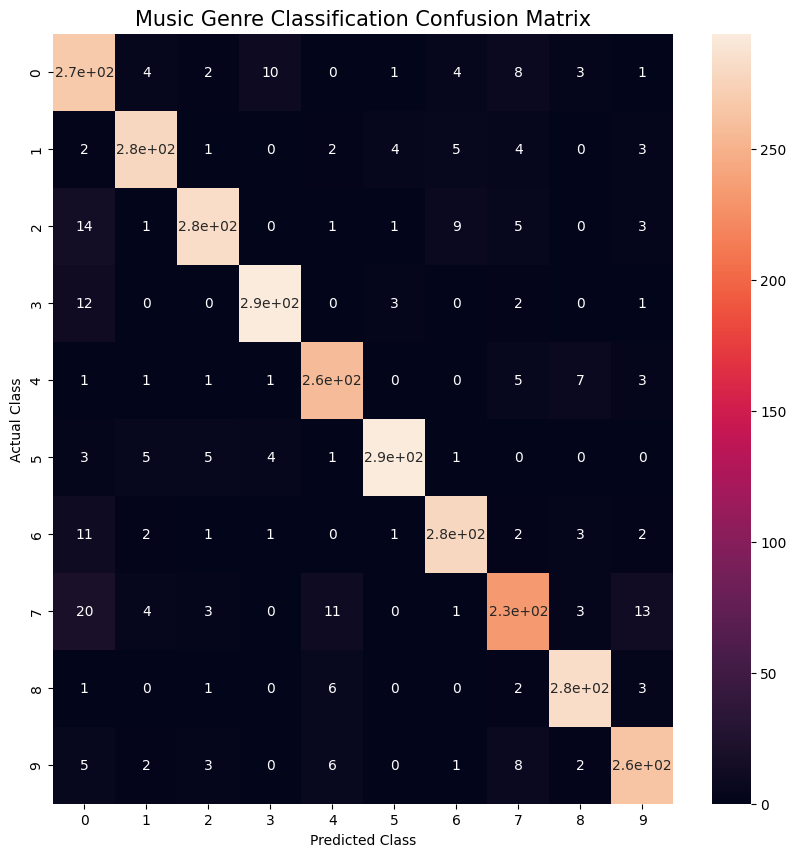

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":10})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Music Genre Classification Confusion Matrix",fontsize=15)
plt.show()

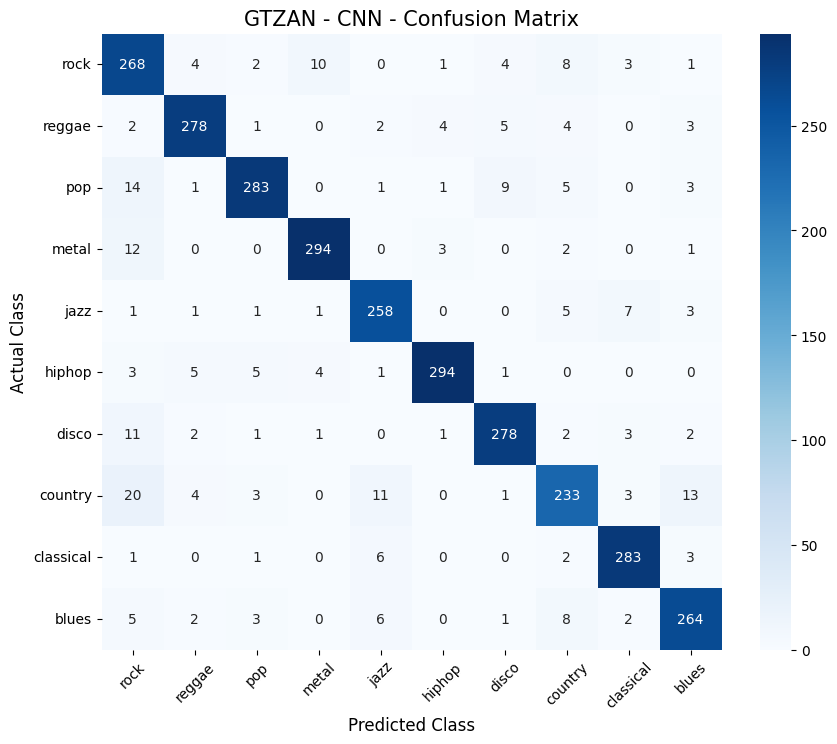

In [ ]:
cm = confusion_matrix(trueCategories, predictedCategories)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.title("GTZAN - CNN - Confusion Matrix", fontsize=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

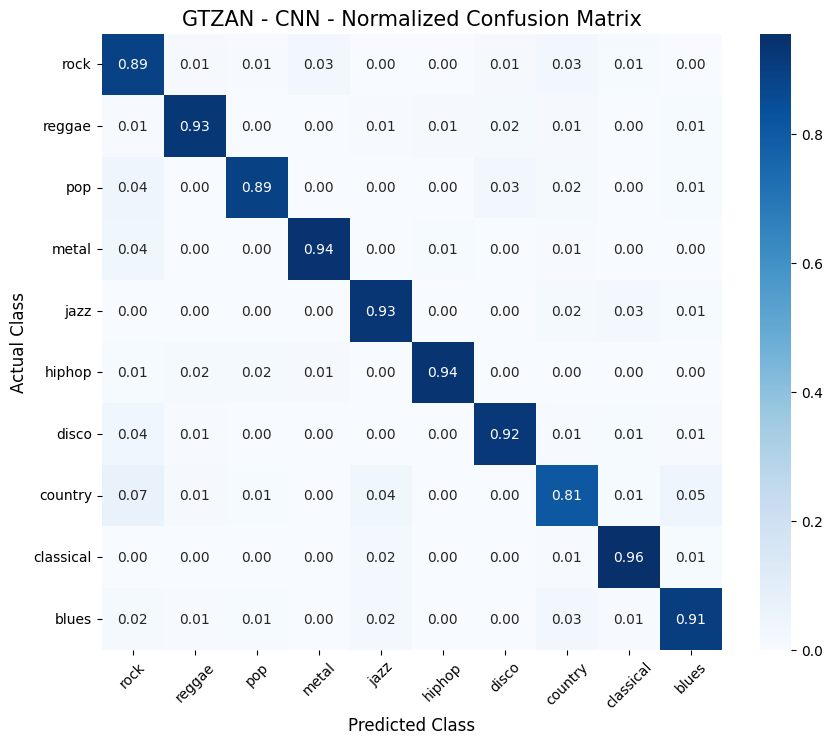

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)

plt.title("GTZAN - CNN - Normalized Confusion Matrix", fontsize=15)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()